<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_06_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz')
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44701,https://www.airbnb.com/rooms/44701,20250923203114,2025-09-24,previous scrape,"Jan 4-11,2026 CES: 2beds,2baths, 1020 sqft,sle...",Experience the luxury of our well-appointed vi...,This 19.5-acre gated community is 1 block from...,https://a0.muscache.com/pictures/1218626b-295f...,189245,...,5.00,4.75,4.50,Exempt,f,2,2,0,0,0.04
1,113019,https://www.airbnb.com/rooms/113019,20250923203114,2025-09-24,city scrape,MGM Signature Studio !,"*3 night minimum, MAY accept two night stay on...",NaN,https://a0.muscache.com/pictures/56149560/d180...,575684,...,4.44,4.81,4.61,Exempt,f,10,9,1,0,1.20
2,114140,https://www.airbnb.com/rooms/114140,20250923203114,2025-09-24,city scrape,MGM Signature 1BR/2BA Suite W/ View,"*3 night minimum, will accept 2 nights on occa...",NaN,https://a0.muscache.com/pictures/56068170/7fa6...,575684,...,4.41,4.77,4.64,Exempt,f,10,9,1,0,1.02
3,133084,https://www.airbnb.com/rooms/133084,20250923203114,2025-09-24,city scrape,"Beautiful, Sleek, Sexy Condo - Long Term Rental","This immaculate, modern loft is available for ...",NaN,https://a0.muscache.com/pictures/30c3a88e-3c4b...,653641,...,5.00,4.50,5.00,NaN,t,1,1,0,0,0.01
4,143096,https://www.airbnb.com/rooms/143096,20250923203114,2025-09-24,city scrape,"Las Vegas House with Private Pool 2,000 sq ft","Renting entire 2,000 square feet home, 3 bedro...",The neighborhood is quiet and family oriented.,https://a0.muscache.com/pictures/b3c4bba8-ebb8...,694506,...,4.89,4.78,4.69,NaN,f,1,1,0,0,1.51


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

### In your markdown:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?



,Missing Count,Missing Percentage
estimated_revenue_l365d,5409,30.691103
price,5409,30.691103
bathrooms,5408,30.685429
review_scores_checkin,4268,24.216977
review_scores_location,4268,24.216977
review_scores_value,4268,24.216977
review_scores_cleanliness,4266,24.205629
last_review,4266,24.205629
first_review,4266,24.205629
review_scores_accuracy,4266,24.205629


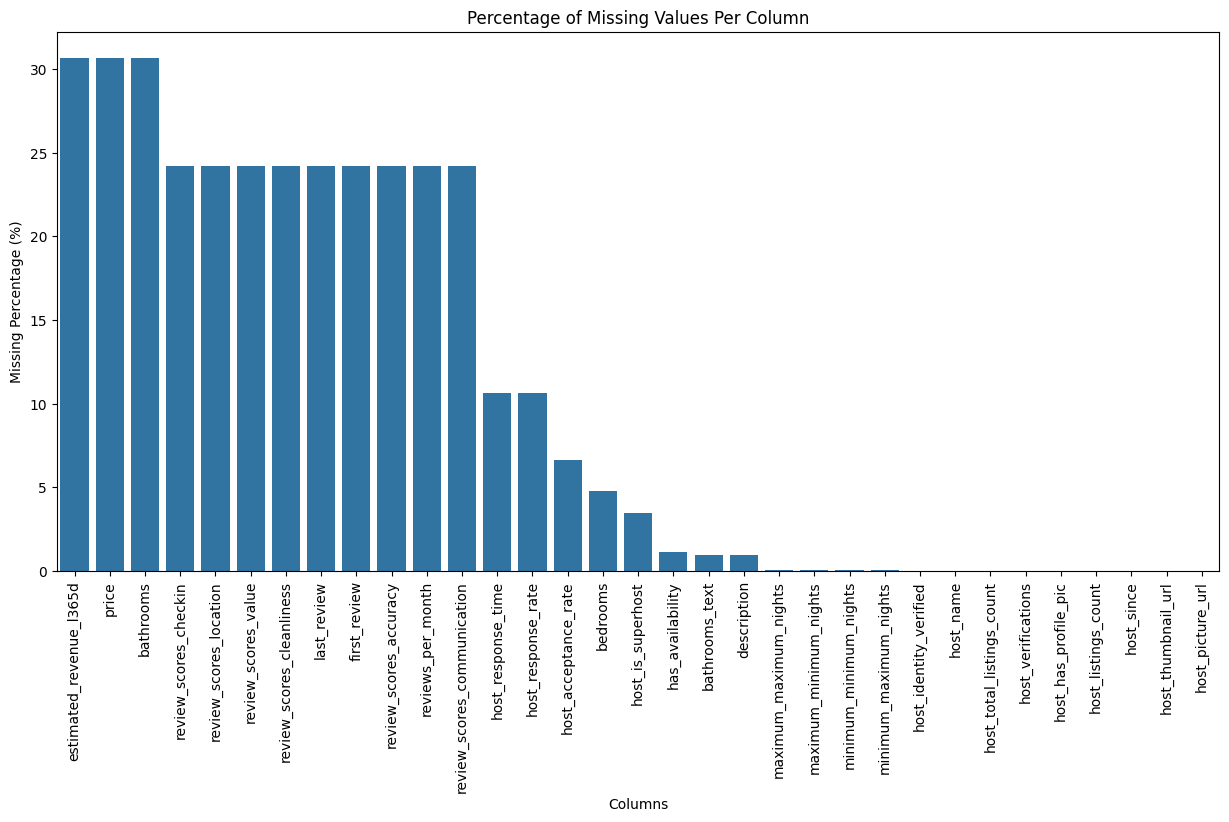

In [ ]:
# Calculate the number of null values for each column
missing_counts = df.isnull().sum()

# Calculate the percentage of null values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Combine counts and percentages into a DataFrame for better readability
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

display(missing_info.head(20)) # Display top 20 columns with most missing values

# Bar plot of missing values for columns with missing data
plt.figure(figsize=(15, 7))
sns.barplot(x=missing_info.index, y=missing_info['Missing Percentage'])
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values Per Column')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.show()

### ✍️ Your Response: 🔧
1. The three columns with the most missing values are neighborhood_group_cleansed, calendar_updated, and neighborhood_overview. Neighborhood_group_cleansed and calendar_updated have the most at 100%.

2. The price, bathrooms, and beds are the columns the most likely to create a business issue.

3. Neighborhood_group_cleansed and calendar_updated are safest columns to be ignored or dropped, since they no values.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

### In Your Response:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?



In [ ]:
# Drop columns identified as not useful or with many missing values
columns_to_drop = ['neighbourhood_group_cleansed','calendar_updated']
df = df.drop(columns=columns_to_drop, errors='ignore') # ignore the error

# Confirm columns are dropped by displaying DataFrame info
display(df.head(10))

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44701,https://www.airbnb.com/rooms/44701,20250923203114,2025-09-24,previous scrape,"Jan 4-11,2026 CES: 2beds,2baths, 1020 sqft,sle...",Experience the luxury of our well-appointed vi...,https://a0.muscache.com/pictures/1218626b-295f...,189245,https://www.airbnb.com/users/show/189245,...,5.00,5.00,4.75,4.50,f,2,2,0,0,0.04
1,113019,https://www.airbnb.com/rooms/113019,20250923203114,2025-09-24,city scrape,MGM Signature Studio !,"*3 night minimum, MAY accept two night stay on...",https://a0.muscache.com/pictures/56149560/d180...,575684,https://www.airbnb.com/users/show/575684,...,4.66,4.44,4.81,4.61,f,10,9,1,0,1.20
2,114140,https://www.airbnb.com/rooms/114140,20250923203114,2025-09-24,city scrape,MGM Signature 1BR/2BA Suite W/ View,"*3 night minimum, will accept 2 nights on occa...",https://a0.muscache.com/pictures/56068170/7fa6...,575684,https://www.airbnb.com/users/show/575684,...,4.56,4.41,4.77,4.64,f,10,9,1,0,1.02
3,133084,https://www.airbnb.com/rooms/133084,20250923203114,2025-09-24,city scrape,"Beautiful, Sleek, Sexy Condo - Long Term Rental","This immaculate, modern loft is available for ...",https://a0.muscache.com/pictures/30c3a88e-3c4b...,653641,https://www.airbnb.com/users/show/653641,...,5.00,5.00,4.50,5.00,t,1,1,0,0,0.01
4,143096,https://www.airbnb.com/rooms/143096,20250923203114,2025-09-24,city scrape,"Las Vegas House with Private Pool 2,000 sq ft","Renting entire 2,000 square feet home, 3 bedro...",https://a0.muscache.com/pictures/b3c4bba8-ebb8...,694506,https://www.airbnb.com/users/show/694506,...,4.93,4.89,4.78,4.69,f,1,1,0,0,1.51
5,169335,https://www.airbnb.com/rooms/169335,20250923203114,2025-09-24,previous scrape,Corp Private room for rent with private bath,"downstairs bedroom with double size bed, fully...",https://a0.muscache.com/pictures/f06a38e9-31cf...,806881,https://www.airbnb.com/users/show/806881,...,4.97,4.97,4.77,4.83,f,2,0,2,0,0.26
6,201619,https://www.airbnb.com/rooms/201619,20250923203114,2025-09-24,previous scrape,Las Vegas Luxury house with the pool,"The best Las Vegas location - South West, Spri...",https://a0.muscache.com/pictures/miso/Hosting-...,974021,https://www.airbnb.com/users/show/974021,...,4.72,4.64,4.69,4.53,t,1,1,0,0,0.73
7,202452,https://www.airbnb.com/rooms/202452,20250923203114,2025-09-23,city scrape,Las Vegas Excitement/Romantic Stay,Our vacation house is close to all the excitem...,https://a0.muscache.com/pictures/e99ad0d2-4787...,991487,https://www.airbnb.com/users/show/991487,...,4.99,4.97,4.82,4.90,f,1,1,0,0,2.20
8,216979,https://www.airbnb.com/rooms/216979,20250923203114,2025-09-24,city scrape,1 Bedroom Condo 2 miles to strip 1 block Orleans,1 B/R Condo 2 miles west of The Strip living r...,https://a0.muscache.com/pictures/fdbf831c-4cc6...,773999,https://www.airbnb.com/users/show/773999,...,4.61,4.70,4.77,4.62,t,1,1,0,0,1.33
9,243305,https://www.airbnb.com/rooms/243305,20250923203114,2025-09-24,city scrape,las Vegas holiday resort 1 week (51),"We offer one week from Dec. 22 to 29, 2017. T...",https://a0.muscache.com/pictures/2294918/73a14...,65714,https://www.airbnb.com/users/show/65714,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN


### ✍️ Your Response: 🔧
1. I dropped the columns neighbourhood_group_cleansed and calendar_updated.

2. I removed these columns because they were 100% missing. Since they do not provide any information bor business decision making, they are safe to drop.

3. The model would have extra complexity and size if I left them in. Removing them makes the data easier to process.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

### In your response:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

In [ ]:
# Fill missing values in beds with the median
df['beds'].fillna(df['beds'].median(), inplace=True)

# Fill missing values in review_scores_rating with the median
df['review_scores_rating'].fillna(df['review_scores_rating'].median(), inplace=True)

# Display the null counts for the cleaned columns
print("Missing values after filling:")
display(df[['beds', 'review_scores_rating']].isnull().sum())

Missing values after filling:


/tmp/ipython-input-3718620295.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['beds'].fillna(df['beds'].median(), inplace=True)
/tmp/ipython-input-3718620295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
beds,0
review_scores_rating,0


### ✍️ Your Response: 🔧
1. I cleaned the beds and review_score_rating column.

2. I filled the missing values using the median, because it is less affected my outliers compared to mean.

3. The risks in filling the data is that they may be inaccurate in comparison to ther variables. It could also reduce variability.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

### In Your Response: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?


In [ ]:
# Clean and convert the price column
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check the data type and get a summary of cleaned column
display(df['price'].describe())

,price
count,12215.000000
mean,520.393451
std,3195.163558
min,3.000000
25%,85.000000
50%,148.000000
75%,241.000000
max,100000.000000


### ✍️ Your Response: 🔧
1. I fixed the price column.

2. I converted the column from a string to a float and removed the dollar signs and commas.

3. This helps to prepare the data for later use because converting price from a string to float allows for numerical calculations.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

### In your markdown:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?


In [ ]:
# Check for duplicate rows
exact_duplicates_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates_count}")

# Check for duplicate id values
id_duplicates_count = df['id'].duplicated().sum()
print(f"Number of duplicate 'id' values: {id_duplicates_count}")

Number of exact duplicate rows: 0
Number of duplicate 'id' values: 0


### ✍️ Your Response: 🔧 🔧
1. I did not find any duplicates.

2. No duplicates were found, so no decision was necessary.

3. Duplicates are risky because they can cause misleading data. This can lead to incorrect decision making for users and the people listing.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [ ]:
# Export the cleaned DataFrame to a CSV file
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### In your markdown:
1. What was the most surprising or challenging part of cleaning this dataset?
2. How did you decide which data to drop, fix, or keep?
3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most surprising part of cleaning this dataset was the high ammount of missing values, across several columns. I was also surprised to see that there were two columns with no data at all.

2. I made decisions based off how much data was missing or duplicated. My decision to drop neighbourhood_group_cleansed and calendar_updated were because they had 100% missing data. Meaning these columns wouln't help us to make decisions whatsoever. They would only be a burden.

3. One way a business team would benefit is being able to make mathematical calculations with price for analysis.

4. If I had more time I would dive deeper into host_response_time and host_response_rate. Through cleaning and anylzing these, I could be able to find a correlation between the two.

5. This realtes to my customized klearning outcomes because I wanted to find what variables impact project decisions the most. Through data cleaning, important columns surface.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [45]:
!jupyter nbconvert --to html "assignment_06_ThorntonJackson.ipynb"

[NbConvertApp] Converting notebook assignment_06_ThorntonJackson.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 454996 bytes to assignment_06_ThorntonJackson.html
